In [7]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from SRToolkit.evaluation import SR_evaluator
from SRToolkit.utils.symbol_library import SymbolLibrary
from SRToolkit.utils.grammar import Grammar, MaxDepth

In [8]:
class MCTSNode:
    def __init__(self, state, parent=None, applied_rule=None, depth=0, prior=1.0):
        self.state = list(state)
        self.parent = parent
        self.applied_rule = applied_rule
        self.depth = depth
        self.children = []
        self.prior = prior
        self.visits = 0
        self.value = 0.0
        self.rule_path = []
        if parent is not None and applied_rule is not None:
            self.rule_path = parent.rule_path + [applied_rule]
            # LT: Dodal varnostni mehanizem, podobno kot pri simulaciji
            self.log_prob = parent.log_prob + np.log(max(float(applied_rule.weight), 1e-12))
        else:
            self.log_prob = 0.0
        self.applicable_rules = None

    def best_child(self, c_param=1.4, use_puct=True):
        log_parent = np.log(self.visits) if self.visits > 0 else 0.0

        def uct(child):
            if child.visits == 0:
                return float('inf')
            exploitation = child.value / child.visits
            exploration = c_param * np.sqrt(log_parent / child.visits)
            return exploitation + exploration

        def puct(child):
            parent_visits = max(1, self.visits)
            q = 0.0 if child.visits == 0 else child.value / child.visits
            exploration = c_param * child.prior * np.sqrt(parent_visits) / (1 + child.visits)
            return q + exploration

        if use_puct:
            return max(self.children, key=puct)
        else:
            return max(self.children, key=uct)


class Grams:
    def __init__( self, grammar, reward, evaluator=None, error=1e-7, max_rollout_depth=100, c_param=1.4, use_puct=True):
        self.grammar = grammar
        self.reward = reward
        self.evaluator = evaluator
        self.error = error
        self.max_depth = max_rollout_depth
        self.c_param = c_param
        self.use_puct = use_puct

            
        if evaluator is not None:
            self.n_points = evaluator.X.shape[0]
    
        EPS = 1e-6
        probs = {}
        for rule in grammar.to_dict()["rules"]:
            lhs = rule["lhs"]
            probs[lhs] = probs.get(lhs, 0) + rule["weight"]
        for lhs, total_p in probs.items():
            if not ((1.0 - EPS) < total_p < (1.0 + EPS)):
                raise ValueError(f"Productions for {lhs} do not sum to 1")

        grammar.add_constraint(MaxDepth(max_rollout_depth))


    def get_leftmost_nt(self, state):
        for idx, symbol in enumerate(state):
            if symbol in self.grammar.nonterminals:
                return idx, symbol
        return None, None

    def is_terminal(self, state):
        return self.get_leftmost_nt(state)[0] is None

    def _replay_derivation(self, rule_path):
        d = self.grammar.start_derivation(str(self.grammar.start))
        for rule in rule_path:
            d.apply(rule)
        return d

    # LT Dodal to za pravila z verjetnostjo 0
    def _positive_weight_rules(self, rules):
        positive_rules = []
        for rule in rules:
            weight = float(rule.weight)
            if not np.isfinite(weight) or weight < 0:
                raise ValueError(f"Rule {rule} has invalid weight {rule.weight}")
            if weight > 0:
                positive_rules.append(rule)
        return positive_rules

    def _get_applicable(self, node):
        if node.applicable_rules is not None:
            return node.applicable_rules
        derivation = self._replay_derivation(node.rule_path)
        if derivation.complete:
            node.applicable_rules = []
        else:
            node.applicable_rules = self._positive_weight_rules(derivation.options())
        return node.applicable_rules


    # LT Dodal sem random_seed za ponovljivost
    # dodan k_rollouts
    def search(self, iterations, random_seed=None, k_rollouts=1):
        if random_seed is not None:
            random.seed(random_seed)
            np.random.seed(random_seed)

        self.history = []

        if self.evaluator is not None:
            self.min_rmse = float('inf')
            self.best_model = None

        root = MCTSNode([str(self.grammar.start)])

        for i in range(iterations):
            node = self.tree_policy(root)
            # LT Na tem mestu bi lahko dodali multiple simulations per node in računali povprečno nagrado
            rewards = []

            for _ in range(k_rollouts):
                r = self.simulate(node)
                rewards.append(r)
                if self.evaluator is not None and self.min_rmse <= self.error:
                    break 

            avg_reward = sum(rewards) / len(rewards)
            self.backpropagate(node, avg_reward)

            if self.evaluator is not None and self.min_rmse <= self.error:
                print(f"Stopping early at iteration {i} with RMSE {self.min_rmse}")
                return self.evaluator.get_results(top_k=1)

        if self.evaluator is not None:
            if not self.evaluator.models:
                return self.evaluator.get_results(top_k=0)
            results = self.evaluator.get_results(top_k=1)
            if len(results) == 0 or len(results[0].top_models) == 0:
                print("Warning: No valid models found during search.")
            return results

        return self.history

    def tree_policy(self, node):
        while not self.is_terminal(node.state):
            applicable = self._get_applicable(node)

            if not applicable:
                return node

            if len(node.children) < len(applicable):
                return self.expand(node, applicable)

            node = node.best_child(c_param=self.c_param, use_puct=self.use_puct)
        return node
  
    def expand(self, node, applicable):
        tried = [c.applied_rule for c in node.children]
        untried = [prod for prod in applicable if prod not in tried]
        
        weights = [float(prod.weight) for prod in untried]
        prod = random.choices(untried, weights=weights, k=1)[0]
        
        total_applicable_weight = sum(float(rule.weight) for rule in applicable)
        if total_applicable_weight <= 0:
            raise ValueError("Applicable rule weights must sum to a positive value.")
        
        prior = float(prod.weight) / total_applicable_weight
        
        index, _ = self.get_leftmost_nt(node.state)
        new_state = list(node.state)
        new_state[index:index+1] = list(prod.rhs)

        new_node = MCTSNode(
            new_state,
            parent=node,
            applied_rule=prod,
            depth=node.depth + 1,
            prior=prior
        )
        node.children.append(new_node)
        return new_node

    def simulate(self, node):
        if self.evaluator is not None:
            return self._simulate_with_evaluator(node)
        else:
            return self._simulate_basic(node)

    def _simulate_basic(self, node):
        derivation = self._replay_derivation(node.rule_path)

        while not derivation.complete:
            rules = self._positive_weight_rules(derivation.options())
            
            if not rules:
                return 0.0
            
            weights = [float(rule.weight) for rule in rules]
            selected = random.choices(rules, weights=weights, k=1)[0]
            derivation.apply(selected)

        if not derivation.complete:
            return 0.0
        
        tokens = derivation.to_token_list()
        state_str = "".join(str(t) for t in tokens)
        
        reward = self.reward(state_str)
        self.history.append((state_str, reward, None))
        return reward

    def _simulate_with_evaluator(self, node):
        derivation = self._replay_derivation(node.rule_path)
        rollout_log_prob = node.log_prob

        while not derivation.complete:
            surviving_rules = self._positive_weight_rules(derivation.options())
            if not surviving_rules:
                return 0.0

            weights = [float(r.weight) for r in surviving_rules]
            total = sum(weights)
            probs = [w / total for w in weights]

            choice_idx = np.random.choice(len(surviving_rules), p=probs)
            selected_rule = surviving_rules[choice_idx]
            rollout_log_prob += np.log(max(float(selected_rule.weight), 1e-12))
            derivation.apply(selected_rule)

        tokens = derivation.to_token_list()
        state_str = "".join(tokens)

        rmse = self.evaluator.evaluate_expr(tokens)
        if np.isnan(rmse) or np.isinf(rmse):
            return 0.0
        if state_str not in self.evaluator.models:
            return 0.0

        model_res = self.evaluator.models[state_str]
        num_params = len(getattr(model_res, 'parameters', []))

        current_reward = self.reward(
            rmse=rmse,
            k=num_params + 1,
            n=self.n_points,
            log_prob=rollout_log_prob
        )

        if rmse < self.min_rmse:
            self.min_rmse = rmse
            self.best_model = state_str

        self.history.append((state_str, current_reward, rmse))
        return current_reward

    def backpropagate(self, node, reward):
        while node is not None:
            node.visits += 1
            node.value += reward
            node = node.parent

In [55]:
# LT Dodal sem random_seed za ponovljivost
def mc_search(grammar, iterations, utility, random_seed=None):
    if random_seed is not None:
        random.seed(random_seed)
        np.random.seed(random_seed)
    results = []
    for i in range(iterations):
        state = grammar.generate_one()
        reward = utility(state)
        state_string = "".join(str(t) for t in state)
        results.append((state_string, reward, None))
    return results

In [ ]:
# za zacetek vzamemo 3

p_a = 0.1
p_b = 0.5
p_c = 0.9

grammar_str = f"""
    E -> A B C [1.0]
    
    A -> A 'a' [{p_a}]
    A -> 'a'   [{1 - p_a}]
    
    B -> B 'b' [{p_b}]
    B -> 'b'   [{1 - p_b}]
    
    C -> C 'c' [{p_c}]
    C -> 'c'   [{1 - p_c}]
"""

def gini_impurity(expr):
    return 1 - sum(expr.count(c)**2 for c in set(expr))/len(expr)**2

def gini_advanced(expr, gamma, alpha):
    # LT: normalizacija glede na število unikatnih simbolov, tukaj fiksno 3, ni najboljša rešitev
    gini_index_normalized = gini_impurity(expr)/(1 - 1/3)
    # prej:
    # gini_index_normalized = gini_impurity(expr)/(1 - 1/len(set(expr))) if len(set(expr)) > 1 else 0
    length = len(expr)
    return (gini_index_normalized ** gamma)  * (length ** alpha)

def gini_reward(expr):
    return gini_advanced(expr, 10, 0.5)

RS = 1
N = 1000

grammar = Grammar.from_grammar_string(grammar_str, start="E")

tree_search_puct = Grams(grammar, reward=gini_reward, max_rollout_depth=100)
results_mcts_puct = tree_search_puct.search(N, random_seed=RS)

results_mc = mc_search(grammar, N, gini_reward, random_seed=RS)

tree_search_uct = Grams(grammar, reward=gini_reward, max_rollout_depth=100, use_puct=False)
results_mcts_uct = tree_search_uct.search(N, random_seed=RS)

In [15]:
def test_mcts(variables, X, y, reward, grammar_str, start_symbol, iterations=1000, max_rollout_depth=100, k_rollouts=5):
    grammar = Grammar.from_grammar_string(grammar_str, start=start_symbol)
    lib = SymbolLibrary.default_symbols(num_variables=len(variables))
    eval = SR_evaluator(X=X, y=y, symbol_library=lib)
    mcts = Grams(grammar=grammar, reward=reward, evaluator=eval, error=1e-9, max_rollout_depth=max_rollout_depth)
    results = mcts.search(iterations, k_rollouts)
    if results and len(results) > 0 and len(results[0].top_models) > 0:
        print(f"Best model: {results[0].best_expr} with RMSE: {results[0].min_error}")
        return results, mcts.history
    else:
        print("No valid models found during search.")
        return results, mcts.history

In [ ]:
# LT Opazil sem, da moving median je bolj stabilen od moving average,
# zato bi na grafih lahko risali samo moving median

# LT Potrebovali bi funkcijo, ki požene vsako metodo 10x
# in potem nariše graf napredka za vsako metodo, ki predstavi
# mediano in "rokav" med prvim in tretjim kvartilom nagrade
# (računamo jih na nagradah iz 10 poganjanj) skozi iteracije

def plot_progress(results, name, window = 20):

    scores = [item[1] for item in results]
    max_scores = np.maximum.accumulate(scores)

    moving_median = pd.Series(scores).rolling(window=window).median().dropna().to_numpy()

    plt.figure(figsize=(10, 5))
    
    plt.plot(range(len(max_scores)), max_scores, color='blue', linewidth=2, label='nagradna funkcija najboljšega rezultata')
    plt.plot(range(window-1, len(scores)), moving_median, color='green', label='moving median')
    plt.title(name)
    # plt.ylim(0.0, 1.0)
    # plt.xlim(0, len(scores))
    plt.xlabel('Število iteracij')
    plt.ylabel('Funkcija nagrade')
    plt.legend()
    
    plt.show()


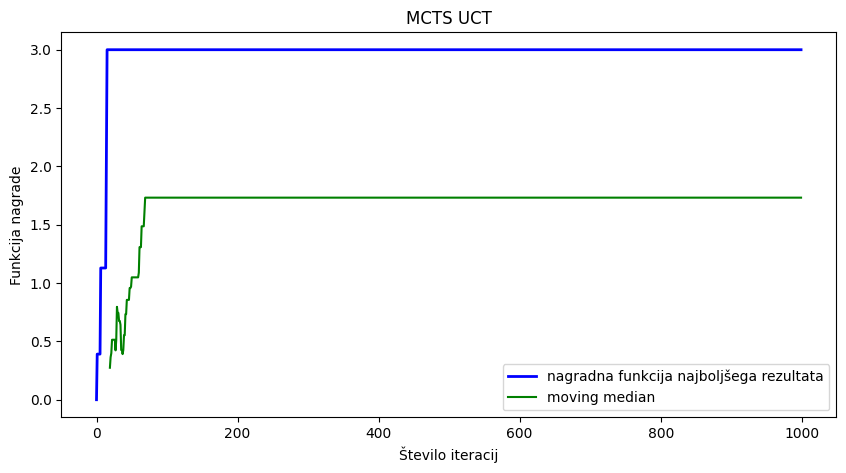

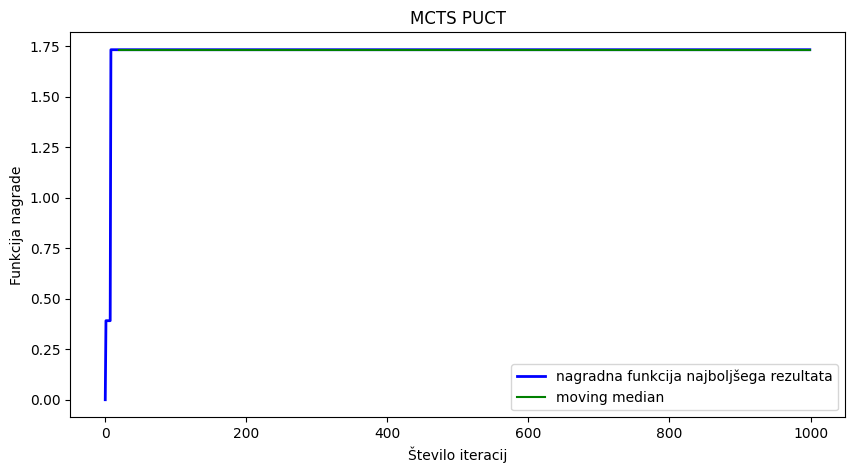

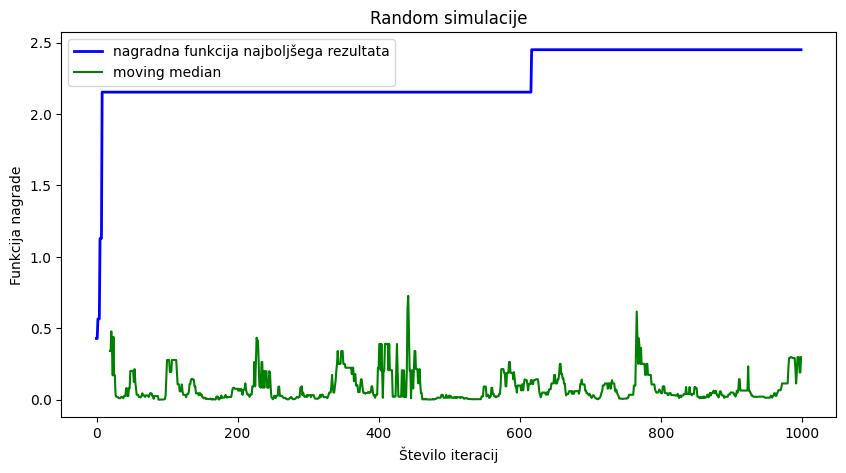

In [69]:
plot_progress(results_mcts_uct, name="MCTS UCT")
plot_progress(results_mcts_puct, name="MCTS PUCT")
plot_progress(results_mc, name="Random simulacije")

In [14]:
def run_n_times(method, n_runs=10):
    all_results = []

    for run in range(n_runs):
        results = method(random_seed=run)
        all_results.append(results)

    return all_results

In [63]:
def plot_progress_n_runs(all_results, name):
    runs = []

    for results in all_results:
        scores = [item[1] for item in results]

        scores = np.maximum.accumulate(scores)

        runs.append(scores)

    max_len = max(len(r) for r in runs)
    runs = np.array([
        np.pad(r, (0, max_len - len(r)), mode="edge")
        for r in runs
    ])

    median = np.median(runs, axis=0)
    q1 = np.percentile(runs, 25, axis=0)
    q3 = np.percentile(runs, 75, axis=0)

    x = np.arange(max_len)

    plt.figure(figsize=(10, 5))

    plt.plot(
        x,
        median,
        linewidth=2,
        label="Mediana"
    )

    plt.fill_between(
        x,
        q1,
        q3,
        alpha=0.25,
        label="Q1–Q3"
    )

    plt.title(name)
    plt.xlabel("Število iteracij")
    plt.ylabel("Funkcija nagrade")
    plt.legend()

    plt.show()

In [78]:
all_methods = {
    "MCTS-PUCT": run_n_times(
        lambda random_seed: tree_search_puct.search(N, random_seed=random_seed)
    ),
    "MCTS-UCT": run_n_times(
        lambda random_seed: tree_search_uct.search(N, random_seed=random_seed)
    ),
    "MC": run_n_times(
        lambda random_seed: mc_search(
            grammar,
            N,
            gini_reward,
            random_seed=random_seed
        )
    ),
    "MCTS-PUCT_5": run_n_times(
        lambda random_seed: tree_search_puct.search(N, random_seed=random_seed, k_rollouts=5)
    ) 
}

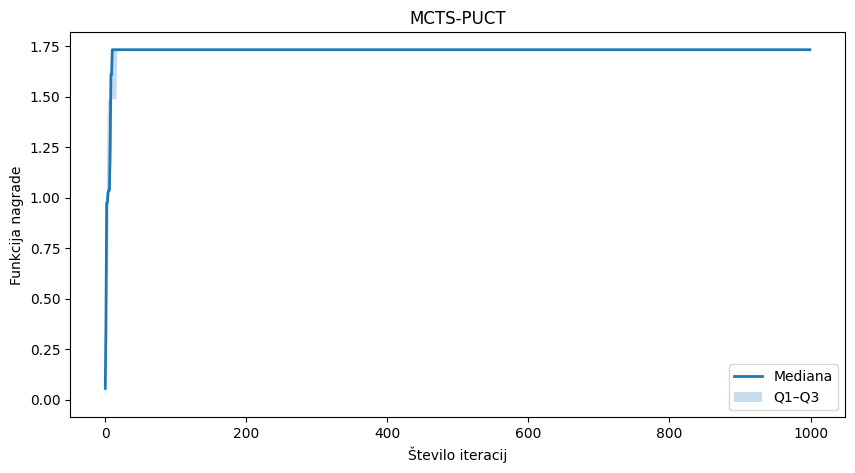

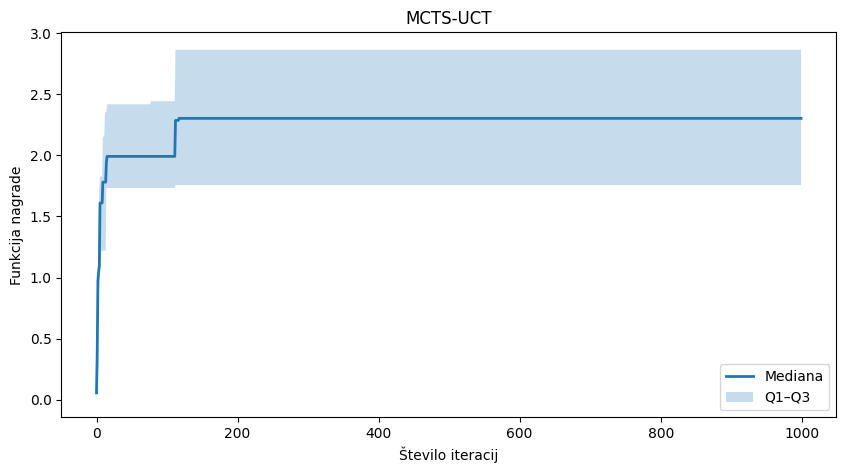

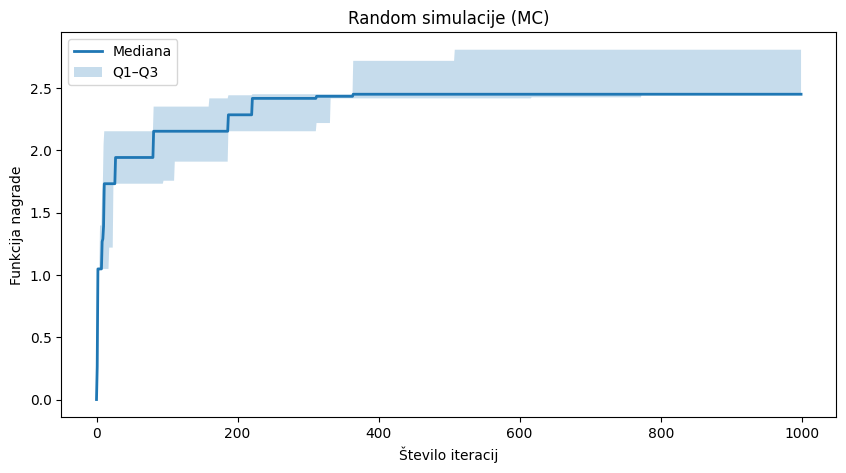

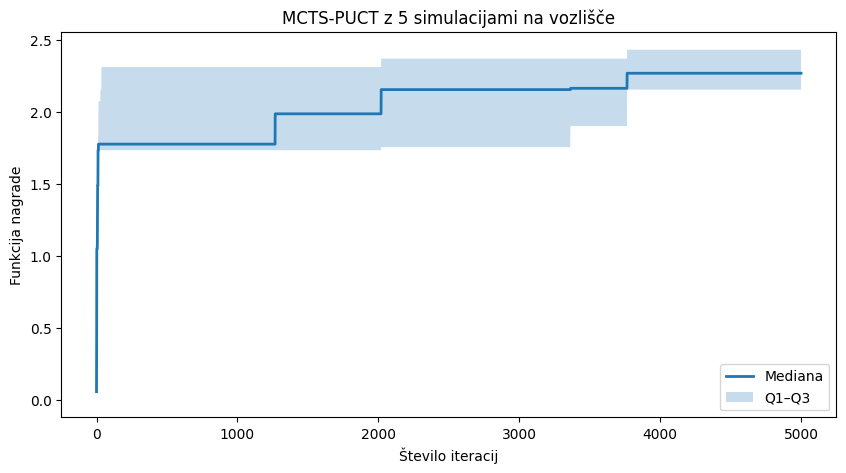

In [79]:
plot_progress_n_runs(all_methods["MCTS-PUCT"], "MCTS-PUCT")
plot_progress_n_runs(all_methods["MCTS-UCT"], "MCTS-UCT")
plot_progress_n_runs(all_methods["MC"], "Random simulacije (MC)")
plot_progress_n_runs(all_methods["MCTS-PUCT_5"], "MCTS-PUCT z 5 simulacijami na vozlišče")


In [16]:
variables = ["X_0", "X_1"]
grammar = "E -> E '+' F [0.2] | E '-' F [0.2] | F [0.6]\n"
grammar += "F -> F '*' T [0.2] | F '/' T [0.2] | T [0.6]\n"
grammar += "T -> '(' E ')' [0.2] | V [0.6] | 'sin' '(' E ')' [0.2]\n"
grammar += "\n".join([f"V -> '{v}' [{1/len(variables)}]" for v in variables])

N = 100
x_train = np.random.uniform(-5, 5, (N, len(variables)))
y_train = x_train[:, 1] / x_train[:, 0]

# preprosta funkcija nagrade za testiranje (samo z napako RMSE)
def reward_rmse(*, rmse, **kwargs):
    return -rmse

results, history = test_mcts(variables, x_train, y_train, reward_rmse, grammar, 'E', iterations=1000,  max_rollout_depth=15)

Best model: sin(X_0/sin(X_0)-X_0-(X_1))+sin(X_1)/(X_0)+X_0+sin(X_1/sin((X_1)-(X_1)*X_0))*X_0 with RMSE: 6.205248026966411


In [20]:
variables = ["X_0", "X_1", "X_2"]
grammar_str = "E -> E '+' T [0.4] | T [0.6]\n"
grammar_str += "T -> 'C' '*' V [0.7] | V [0.3]\n"
grammar_str += "\n".join([f"V -> '{v}' [{1/len(variables)}]" for v in variables])

N = 100
x_train = np.random.uniform(-5, 5, (N, len(variables)))
y_train = 2.5 * x_train[:, 0] -2 * x_train[:, 1] + 4 * x_train[:, 2]

results, history = test_mcts(variables, x_train, y_train, reward_rmse, grammar_str, 'E', iterations=1000,  max_rollout_depth=10000)

Best model: C*X_2+C*X_0+C*X_1 with RMSE: 6.772279787500133e-07


In [83]:
variables = ["X_0", "X_1", "X_2", "X_3"]
grammar = "E -> E '+' F [0.2] | E '-' F [0.2] | F [0.6]\n"
grammar += "F -> F '*' T [0.2] | F '/' T [0.2] | T [0.6]\n"
grammar += "T -> '(' E ')' [0.2] | V [0.6] | 'sin' '(' E ')' [0.2]\n"
grammar += "\n".join([f"V -> '{v}' [{1/len(variables)}]" for v in variables])

N = 1000
x_train = np.random.uniform(-5, 5, (N, len(variables)))
y_train = x_train[:, 0] - 3*x_train[:, 1] - x_train[:, 2] - x_train[:, 3]

results, history = test_mcts(variables, x_train, y_train, reward_rmse, grammar, 'E', iterations=1000,  max_rollout_depth=1000, k_rollouts=5)

Best model: ((sin(X_2)-(X_1-sin(X_1))-X_3)) with RMSE: 6.9241152036803495


In [12]:
def reward_new(rmse, k,n,log_prob):
    log_posterior = - k/2 * np.log(n) + log_prob - n/2*np.log(2*np.pi) -n/2 - n*np.log(rmse)
    return log_posterior

In [ ]:
variables = ["X_0", "X_1", "X_2", "X_3"]
grammar = "E -> E '+' F [0.2] | E '-' F [0.2] | F [0.6]\n"
grammar += "F -> F '*' T [0.2] | F '/' T [0.2] | T [0.6]\n"
grammar += "T -> '(' E ')' [0.2] | V [0.6] | 'sin' '(' E ')' [0.2]\n"
grammar += "\n".join([f"V -> '{v}' [{1/len(variables)}]" for v in variables])

N = 1000
x_train = np.random.uniform(-5, 5, (N, len(variables)))
y_train = x_train[:, 0] - 3*x_train[:, 1] - x_train[:, 2] - x_train[:, 3]

results, history = test_mcts(variables, x_train, y_train, reward_new, grammar, 'E', iterations=2000,  max_rollout_depth=1000)


Best model: (X_0)-X_1 with RMSE: 7.026804425190218


In [84]:
def plot_progress_rmse(results, name, window=20):

    rmses = np.array([item[2] for item in results], dtype=float)
    best_rmse = np.minimum.accumulate(rmses)

    # moving_avg = np.convolve(rmses, np.ones(window)/window, mode='valid')
    
    plt.figure(figsize=(10, 5))
    moving_median = pd.Series(rmses).rolling(window=window).median().dropna().to_numpy()

    # plt.scatter(range(len(rmses)), rmses, color='black', alpha=0.5, s=5, label='RMSE v iteraciji')
    plt.plot(range(len(best_rmse)), best_rmse, color='blue', linewidth=2, label='najmanjši RMSE do zdaj')
    plt.plot(range(window-1, len(rmses)), moving_median, color='green', label='moving median')
    plt.title(name)
    plt.xlabel('Število iteracij')
    plt.ylabel('RMSE')
    plt.legend()

    plt.show()


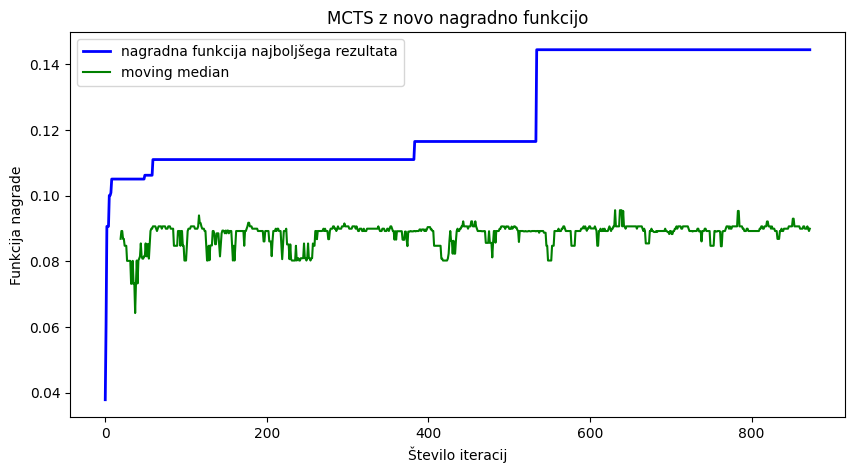

In [85]:
plot_progress(history, name="MCTS z novo nagradno funkcijo")

In [ ]:
from SRToolkit.dataset import Feynman

def build_default_grammar(n_variables):
    variables = [f"X_{i}" for i in range(n_variables)]
    grammar = "E -> E '+' F [0.2] | E '-' F [0.2] | F [0.6]\n"
    grammar += "F -> F '*' T [0.2] | F '/' T [0.2] | T [0.6]\n"
    grammar += "T -> R [0.2] | V [0.6] | 'C' [0.2]\n"
    grammar += "R -> '(' E ')' [0.6] | 'sqrt' '(' E ')' [0.1] |'cos' '(' E ')' [0.1] | 'exp' '(' E ')' [0.1]| 'sin' '(' E ')' [0.1]\n"
    grammar += "\n".join([f"V -> '{v}' [{1/len(variables)}]" for v in variables])
    return variables, grammar

def mc_search_with_evaluator(grammar, iterations, evaluator, error=1e-7, random_seed=None):
    if random_seed is not None:
        random.seed(random_seed)
        np.random.seed(random_seed)

    min_rmse = float("inf")
    best_expr = None
    history = []

    for i in range(iterations):
        tokens = grammar.generate_one()
        state_str = "".join(str(t) for t in tokens)
        rmse = evaluator.evaluate_expr(tokens)
        if np.isnan(rmse) or np.isinf(rmse):
            history.append((state_str, 0.0, None))
            continue
        history.append((state_str, reward_rmse(rmse=rmse), rmse))
        if rmse < min_rmse:
            min_rmse = rmse
            best_expr = state_str
        if min_rmse <= error:
            break

    success = evaluator.success_threshold is not None and min_rmse < evaluator.success_threshold
    return {
        "success": success,
        "min_error": min_rmse,
        "best_expr": best_expr,
        "evaluation_calls": len(history),
    }, history

In [ ]:
# manjka več zagonov

def equation_discovery_feynman(dataset_names, iterations=10000, max_rollout_depth=30, seed=0, k_rollouts=1):
    benchmark = Feynman()
    rows = []

    for name in dataset_names:
        dataset = benchmark.create_dataset(name, seed=seed)

        n_vars = dataset.X.shape[1]
        variables, grammar_str = build_default_grammar(n_vars)
        error_threshold = dataset.success_threshold if dataset.success_threshold is not None else 1e-7

        for method_name in ["MCTS-PUCT", "MCTS-UCT", "MC"]:
            try:
                grammar = Grammar.from_grammar_string(grammar_str, start="E")
                lib = SymbolLibrary.default_symbols(num_variables=n_vars)
                evaluator = SR_evaluator(X=dataset.X, y=dataset.y, symbol_library=lib,
                                         success_threshold=error_threshold)

                if method_name == "MC":
                    grammar.add_constraint(MaxDepth(max_rollout_depth))
                    result, _ = mc_search_with_evaluator(grammar, iterations, evaluator,
                                                          error=error_threshold, random_seed=seed)
                else:
                    mcts = Grams(grammar=grammar, reward=reward_rmse, evaluator=evaluator,
                                 error=error_threshold, max_rollout_depth=max_rollout_depth,
                                 use_puct=(method_name == "MCTS-PUCT"))
                    results = mcts.search(iterations, random_seed=seed, k_rollouts=k_rollouts)
                    if results and len(results) > 0 and len(results[0].top_models) > 0:
                        result = {"success": results[0].success, "min_error": results[0].min_error,
                                  "best_expr": results[0].best_expr,
                                  "evaluation_calls": results[0].evaluation_calls}
                    else:
                        result = {"success": False, "min_error": float("inf"),
                                  "best_expr": None, "evaluation_calls": 0}
            except Exception as e:
                result = {"success": False, "min_error": float("inf"), "best_expr": None,
                          "evaluation_calls": 0}
                print(f"[napaka] {name} / {method_name}: {e}")

            rows.append({
                "equation_id": name,
                "method": method_name,
                "n_variables": n_vars,
                "success": bool(result["success"]),
                "min_error": result["min_error"],
                "best_expr": result["best_expr"],
                "evaluation_calls": result["evaluation_calls"]
            })

    return pd.DataFrame(rows)


In [17]:
dataset_names = Feynman().list_datasets(verbose=False)
feynman_results = equation_discovery_feynman(dataset_names, iterations=300)
feynman_results.head()

Stopping early at iteration 21 with RMSE 6.0398963523944e-09
Stopping early at iteration 28 with RMSE 2.3386598907138078e-08
Stopping early at iteration 271 with RMSE 2.43878881577261e-09
Stopping early at iteration 36 with RMSE 0.0
Stopping early at iteration 137 with RMSE 9.462971122474837e-08
Stopping early at iteration 23 with RMSE 8.447505419491954e-10
Stopping early at iteration 34 with RMSE 2.199778682214112e-15


,equation_id,method,n_variables,success,min_error,best_expr,evaluation_calls
0,I.6.2a,MCTS-PUCT,1,False,4.945091e-03,C/X_0+C,295
1,I.6.2a,MCTS-UCT,1,False,4.763198e-03,C*X_0-C/X_0+X_0-X_0/C*C/X_0-X_0/X_0*X_0/X_0,278
2,I.6.2a,MC,1,False,8.586869e-03,C*X_0-C/X_0,300
3,I.12.1,MCTS-PUCT,2,True,6.039896e-09,C+X_0*X_1,21
4,I.12.1,MCTS-UCT,2,False,8.400330e-01,(X_1-X_1/C)+X_1/X_1-(X_1*X_1-X_1*C/X_1*C/C-X_0...,296


In [18]:
summary = feynman_results.groupby("method").agg(
    solved=("success", "sum"),
    total=("success", "count"),
    median_min_error=("min_error", "median")
).reset_index()
summary["solve_rate"] = summary["solved"] / summary["total"]
summary

,method,solved,total,median_min_error,solve_rate
0,MC,9,100,0.585572,0.09
1,MCTS-PUCT,4,100,1.155269,0.04
2,MCTS-UCT,3,100,0.714018,0.03
